# 📊 Model Comparison & Feature Analysis

This notebook compares all trained Stage 2 regression models and visualises
which features each model relies on most.

**Models compared:**
1. RandomForest
2. XGBoost
3. LightGBM
4. HistGBR
5. CatBoost
6. Stacking Ensemble (Ridge meta-learner over all 5)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')

# Paths
BASE_DIR = Path('.').resolve().parent
DATA_PATH = BASE_DIR / 'data' / 'CleanupDataSet' / 'final_model_ev_updated.csv'
SAVE_DIR = Path('.').resolve() / 'saved_models'

print(f'Data: {DATA_PATH}')
print(f'Models: {SAVE_DIR}')
print(f'Files: {[f.name for f in sorted(SAVE_DIR.glob("*"))]}')

Data: /home/elsherif/Desktop/Thesis/ViewPython/data/CleanupDataSet/final_model_ev_updated.csv
Models: /home/elsherif/Desktop/Thesis/ViewPython/Training/saved_models
Files: ['lstm_label_encoder.joblib', 'lstm_model.keras', 'lstm_scaler_X.joblib', 'model_metadata.json', 'stage1_classifier.joblib', 'stage2_catboost.joblib', 'stage2_elasticnet.joblib', 'stage2_histgbr.joblib', 'stage2_lightgbm.joblib', 'stage2_randomforest.joblib', 'stage2_ridge.joblib', 'stage2_stacking.joblib', 'stage2_xgboost.joblib']


## 1. Load Data & Models

In [20]:
# Load metadata
with open(SAVE_DIR / 'model_metadata.json') as f:
    metadata = json.load(f)

FEATURE_COLS = metadata['feature_cols']
print(f'Features ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Features (14):
   1. year
   2. total_rooftops
   3. Unemployment_Rate
   4. Average_Age
   5. Elderly_Population
   6. Young_Population
   7. Total_Population
   8. employed
   9. pv_price
  10. panel_area_lag1
  11. ev_points_164m
  12. tile_encoded
  13. tile_centroid_lat
  14. tile_centroid_lon


In [21]:
# Load data and prepare splits (same as training)
df = pd.read_csv(DATA_PATH)
df['panel_area_log'] = np.log1p(df['panel_area_m2'])
df['has_solar'] = (df['panel_area_m2'] > 0).astype(int)

df_model = df.dropna(subset=FEATURE_COLS + ['panel_area_log']).copy()
# upper_cutoff = df_model[df_model['panel_area_log'] > 0]['panel_area_log'].quantile(0.99)
# df_model = df_model[df_model['panel_area_log'] <= upper_cutoff]
df_model = df_model.sort_values('year')

test_year = df_model['year'].max()
val_year = df_model[df_model['year'] < test_year]['year'].max()

train_df = df_model[df_model['year'] < val_year]
val_df = df_model[df_model['year'] == val_year]
test_df = df_model[df_model['year'] == test_year]

train_pos = train_df[train_df['has_solar'] == 1]

X_train = train_pos[FEATURE_COLS]
y_train = train_pos['panel_area_log']
X_test = test_df[FEATURE_COLS]
y_test = test_df['panel_area_log']

print(f'Train (solar>0): {len(X_train):,} rows')
print(f'Test (all):      {len(X_test):,} rows')
print(f'Val year: {val_year}, Test year: {test_year}')

Train (solar>0): 25,306 rows
Test (all):      1,564 rows
Val year: 2023, Test year: 2024


In [22]:
# Load all saved models
model_names = ['RandomForest', 'XGBoost', 'LightGBM', 'HistGBR', 'CatBoost','ridge','elasticnet']
models = {}
for name in model_names:
    path = SAVE_DIR / f'stage2_{name.lower()}.joblib'
    if path.exists():
        models[name] = joblib.load(path)
        size_mb = path.stat().st_size / 1024 / 1024
        print(f'  ✓ Loaded {name:15s}  ({size_mb:.1f} MB)')
    else:
        print(f'  ✗ Missing {name}')

# Load stacking meta-learner
stack_data = joblib.load(SAVE_DIR / 'stage2_stacking.joblib')
meta_learner = stack_data['meta_learner']
print(f'  ✓ Loaded Stacking meta-learner')

# Load Stage 1 classifier
clf = joblib.load(SAVE_DIR / 'stage1_classifier.joblib')
print(f'  ✓ Loaded Stage-1 Classifier')

  ✓ Loaded RandomForest     (764.3 MB)
  ✓ Loaded XGBoost          (4.0 MB)
  ✓ Loaded LightGBM         (5.8 MB)
  ✓ Loaded HistGBR          (1.0 MB)
  ✓ Loaded CatBoost         (0.2 MB)
  ✓ Loaded ridge            (0.0 MB)
  ✓ Loaded elasticnet       (0.0 MB)
  ✓ Loaded Stacking meta-learner
  ✓ Loaded Stage-1 Classifier


---
## 2. Performance Comparison Table

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

results = []
predictions = {}

for name, model in models.items():
    y_pred_log = model.predict(X_test)
    y_pred_real = np.clip(np.expm1(y_pred_log), 0, None)
    y_test_real = np.expm1(y_test.values)

    predictions[name] = y_pred_log  # store for stacking

    results.append({
        'Model': name,
        'Test R² (log)': r2_score(y_test, y_pred_log),
        'Test RMSE (log)': rmse(y_test, y_pred_log),
        'Test R² (real)': r2_score(y_test_real, y_pred_real),
        'Test MAE (m²)': mean_absolute_error(y_test_real, y_pred_real),
        'Test RMSE (m²)': rmse(y_test_real, y_pred_real),
    })

# Stacking predictions
test_stack_input = np.column_stack([predictions[n] for n in model_names])
y_pred_stack = meta_learner.predict(test_stack_input)
y_pred_stack_real = np.clip(np.expm1(y_pred_stack), 0, None)
y_test_real = np.expm1(y_test.values)

results.append({
    'Model': '🏗️ Stacking',
    'Test R² (log)': r2_score(y_test, y_pred_stack),
    'Test RMSE (log)': rmse(y_test, y_pred_stack),
    'Test R² (real)': r2_score(y_test_real, y_pred_stack_real),
    'Test MAE (m²)': mean_absolute_error(y_test_real, y_pred_stack_real),
    'Test RMSE (m²)': rmse(y_test_real, y_pred_stack_real),
})

results_df = pd.DataFrame(results).sort_values('Test MAE (m²)')
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = 'Rank'

# Style the table
styled = results_df.style.format({
    'Test R² (log)': '{:.4f}',
    'Test RMSE (log)': '{:.4f}',
    'Test R² (real)': '{:.4f}',
    'Test MAE (m²)': '{:.2f}',
    'Test RMSE (m²)': '{:.2f}',
}).background_gradient(
    subset=['Test MAE (m²)'], cmap='RdYlGn_r', low=0, high=0.5
).background_gradient(
    subset=['Test R² (real)'], cmap='RdYlGn', low=0, high=0.3
)
styled

,Model,Test R² (log),Test RMSE (log),Test R² (real),Test MAE (m²),Test RMSE (m²)
Rank,,,,,,
1,HistGBR,0.8851,0.7740,0.5127,94.70,568.90
2,🏗️ Stacking,0.8514,0.8802,0.4898,100.65,582.09
3,LightGBM,0.8492,0.8865,0.5075,100.79,571.92
4,CatBoost,0.8498,0.8849,0.4817,101.00,586.68
5,XGBoost,0.8582,0.8598,0.5079,101.24,571.69
6,RandomForest,0.8182,0.9736,0.3608,134.35,651.53
7,ridge,0.0040,2.2785,-2105782309842819255297392479547470905344.0000,945622169020953919488.00,37396935863128148672512.00
8,elasticnet,0.0016,2.2812,-6795751871274786531899372104284280717312.0000,1698750765276485386240.00,67181243734945618198528.00


---
## 3. Visual Comparison: Bar Charts

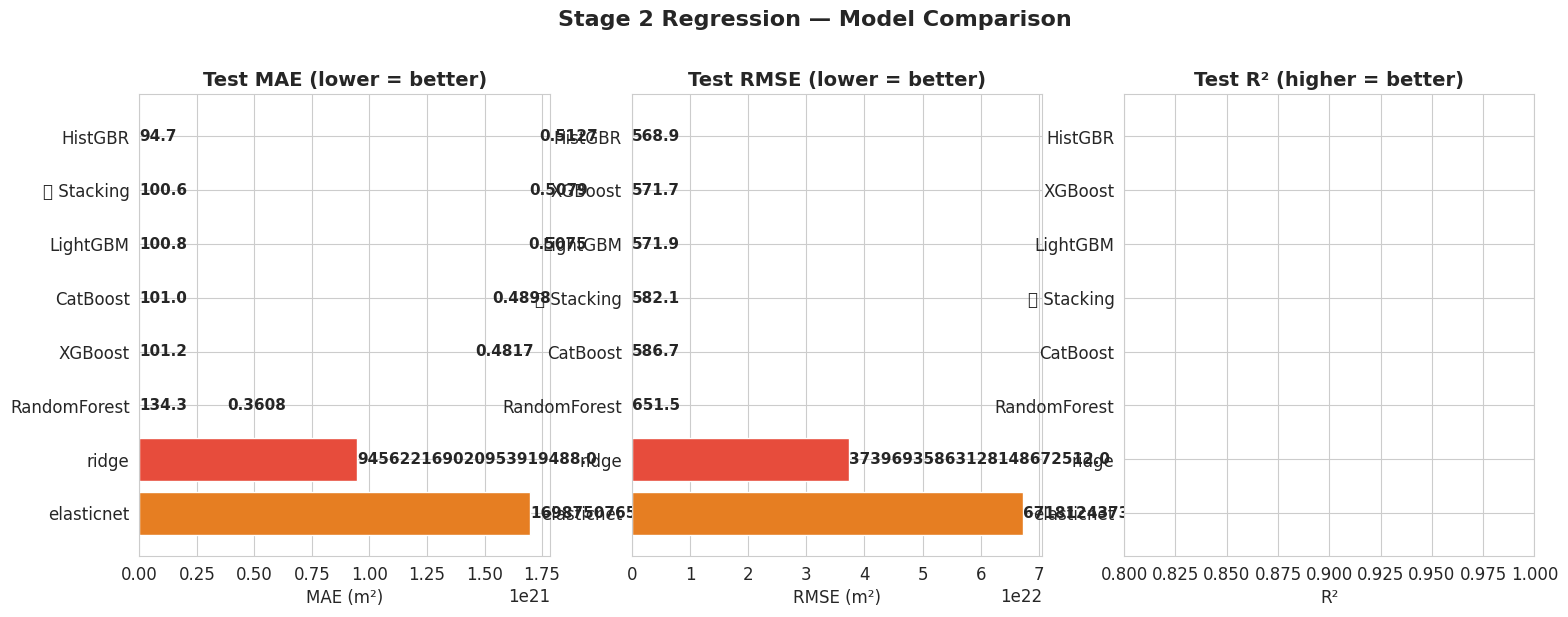

✓ Saved: model_performance_comparison.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6', '#1abc9c']
sorted_df = results_df.sort_values('Test MAE (m²)')

# MAE
bars = axes[0].barh(sorted_df['Model'], sorted_df['Test MAE (m²)'], color=colors)
axes[0].set_xlabel('MAE (m²)')
axes[0].set_title('Test MAE (lower = better)', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, sorted_df['Test MAE (m²)']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=11)

# RMSE
sorted_rmse = results_df.sort_values('Test RMSE (m²)')
bars = axes[1].barh(sorted_rmse['Model'], sorted_rmse['Test RMSE (m²)'], color=colors)
axes[1].set_xlabel('RMSE (m²)')
axes[1].set_title('Test RMSE (lower = better)', fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars, sorted_rmse['Test RMSE (m²)']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=11)

# R²
sorted_r2 = results_df.sort_values('Test R² (real)', ascending=False)
bars = axes[2].barh(sorted_r2['Model'], sorted_r2['Test R² (real)'], color=colors)
axes[2].set_xlabel('R²')
axes[2].set_title('Test R² (higher = better)', fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlim(0.8, 1.0)
for bar, val in zip(bars, sorted_r2['Test R² (real)']):
    axes[2].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

plt.suptitle('Stage 2 Regression — Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: model_performance_comparison.png')

---
## 4. Feature Importance — All Models

Each model weighs features differently. Understanding which features drive predictions
helps validate the model and gives domain insights.

In [25]:
# Collect feature importances
importance_data = {}

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        raw = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        raw = model.get_feature_importance()
    else:
        # HistGBR: use permutation importance
        print(f'  Computing permutation importance for {name}...')
        perm = permutation_importance(model, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
        raw = perm.importances_mean

    # Normalize to percentages
    total = raw.sum()
    importance_data[name] = (raw / total * 100) if total > 0 else raw

# Build DataFrame
imp_df = pd.DataFrame(importance_data, index=FEATURE_COLS)
imp_df.index.name = 'Feature'

# Add average importance
imp_df['Average'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Average', ascending=False)

print('Feature importance (%, normalised):')
imp_df.style.format('{:.2f}%').background_gradient(cmap='YlOrRd', axis=None)

  Computing permutation importance for HistGBR...
  Computing permutation importance for ridge...
  Computing permutation importance for elasticnet...
Feature importance (%, normalised):


,RandomForest,XGBoost,LightGBM,HistGBR,CatBoost,ridge,elasticnet,Average
Feature,,,,,,,,
panel_area_lag1,64.73%,62.20%,16.95%,86.22%,72.83%,81.07%,86.34%,67.19%
total_rooftops,10.77%,4.44%,16.40%,9.92%,3.51%,9.23%,9.60%,9.12%
year,2.66%,5.64%,6.27%,0.00%,7.79%,0.00%,0.00%,3.19%
tile_encoded,3.88%,2.53%,13.70%,0.32%,1.64%,-0.04%,-0.04%,3.14%
tile_centroid_lat,3.34%,2.30%,10.50%,2.57%,0.66%,1.25%,0.00%,2.94%
Young_Population,2.11%,4.01%,3.92%,0.24%,2.41%,3.11%,3.40%,2.74%
pv_price,2.23%,6.32%,3.18%,0.00%,6.68%,0.00%,0.00%,2.63%
tile_centroid_lon,3.16%,2.64%,5.95%,0.13%,2.69%,0.09%,0.00%,2.10%
Elderly_Population,1.54%,2.39%,4.43%,0.19%,0.47%,3.89%,0.08%,1.85%


### 4a. Feature Importance Heatmap

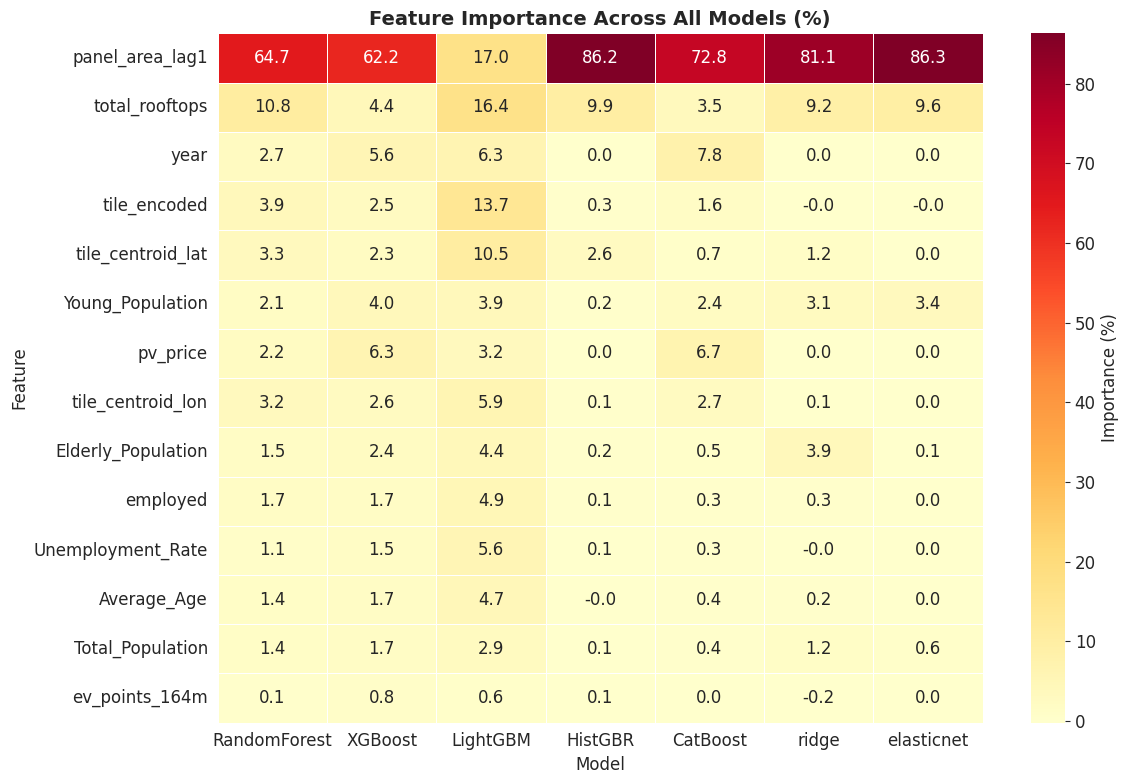

✓ Saved: feature_importance_heatmap.png


In [26]:
fig, ax = plt.subplots(figsize=(12, 8))

# Drop the Average column for the heatmap
heatmap_df = imp_df.drop(columns='Average')

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Importance (%)'}
)
ax.set_title('Feature Importance Across All Models (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: feature_importance_heatmap.png')

### 4b. Feature Importance — Per Model (bar charts)

IndexError: index 6 is out of bounds for axis 0 with size 6

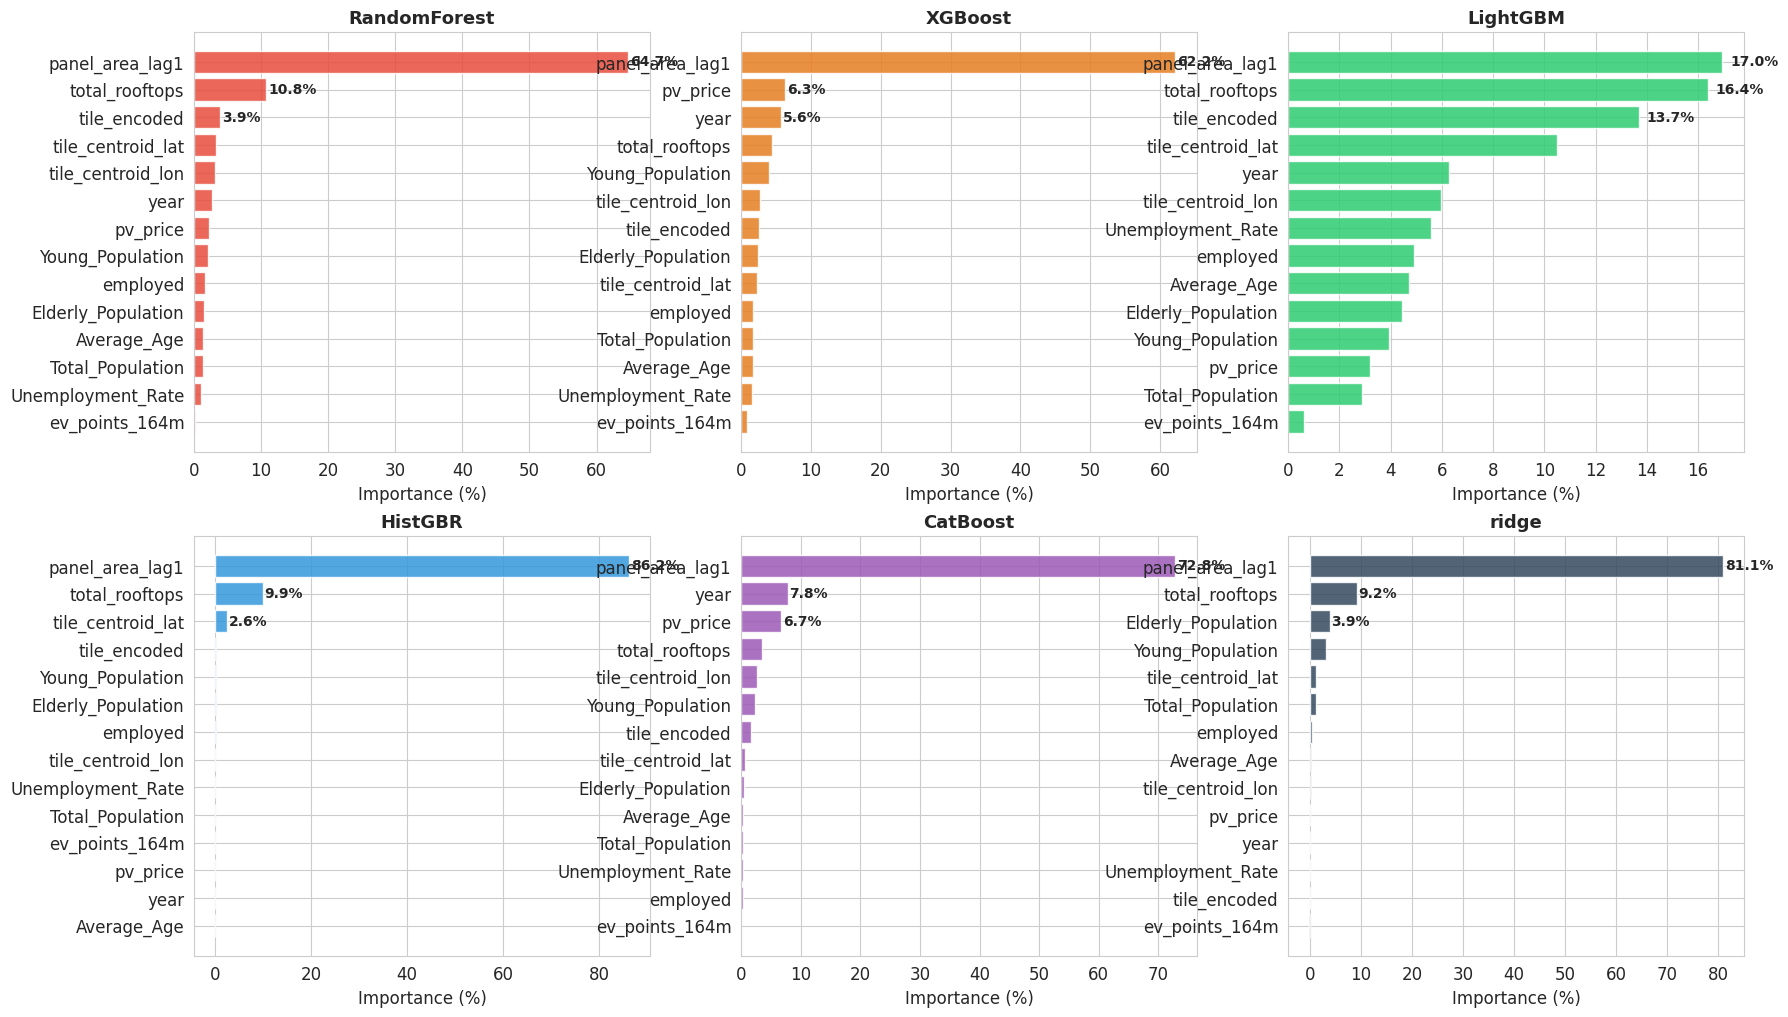

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

model_colors = {
    'RandomForest': '#e74c3c',
    'XGBoost': '#e67e22',
    'LightGBM': '#2ecc71',
    'HistGBR': '#3498db',
    'CatBoost': '#9b59b6',
}

for idx, name in enumerate(model_names):
    ax = axes[idx]
    # Get this model's importances sorted
    series = imp_df[name].sort_values(ascending=True)
    color = model_colors.get(name, '#34495e')
    
    bars = ax.barh(series.index, series.values, color=color, alpha=0.85)
    ax.set_xlabel('Importance (%)')
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    
    # Annotate top 3
    for bar, val in zip(bars, series.values):
        if val > series.values[-4]:  # top 3
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

# Average importance in the 6th subplot
ax = axes[5]
avg_sorted = imp_df['Average'].sort_values(ascending=True)
bars = ax.barh(avg_sorted.index, avg_sorted.values, color='#1abc9c', alpha=0.85)
ax.set_xlabel('Importance (%)')
ax.set_title('Average Across All Models', fontweight='bold', fontsize=13)
for bar, val in zip(bars, avg_sorted.values):
    if val > avg_sorted.values[-4]:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)

plt.suptitle('Feature Importance per Model', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_per_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: feature_importance_per_model.png')

---
## 5. Stacking Meta-Learner Weights

The Ridge meta-learner learned how much to trust each base model:

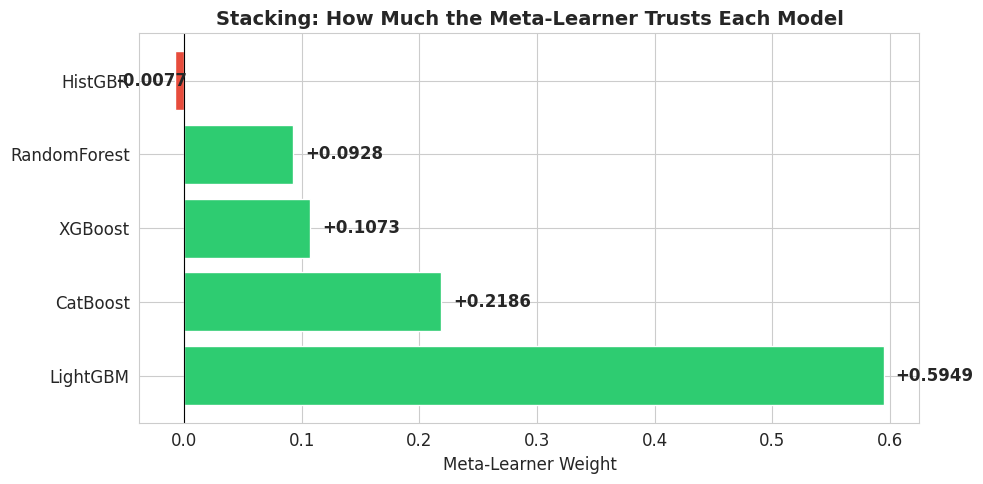


Intercept: -0.0287

Interpretation: The meta-learner relies most on LightGBM (+0.5949)
and CatBoost (+0.2186), with some contribution from XGBoost.
HistGBR has near-zero weight (-0.0077) — its signal is already
captured by the other boosting models.


In [ ]:
weights = dict(zip(model_names, meta_learner.coef_))
weights_df = pd.DataFrame({
    'Model': model_names,
    'Weight': meta_learner.coef_,
    'Abs Weight': np.abs(meta_learner.coef_),
}).sort_values('Abs Weight', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_w = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights_df['Weight']]
bars = ax.barh(weights_df['Model'], weights_df['Weight'], color=colors_w)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Meta-Learner Weight')
ax.set_title('Stacking: How Much the Meta-Learner Trusts Each Model', fontweight='bold')

for bar, val in zip(bars, weights_df['Weight']):
    offset = 0.01 if val >= 0 else -0.05
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('stacking_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIntercept: {meta_learner.intercept_:+.4f}')
print(f'\nInterpretation: The meta-learner relies most on LightGBM ({weights["LightGBM"]:+.4f})')
print(f'and CatBoost ({weights["CatBoost"]:+.4f}), with some contribution from XGBoost.')
print(f'HistGBR has near-zero weight ({weights["HistGBR"]:+.4f}) — its signal is already')
print(f'captured by the other boosting models.')

---
## 6. Prediction Scatter Plots (Actual vs Predicted)

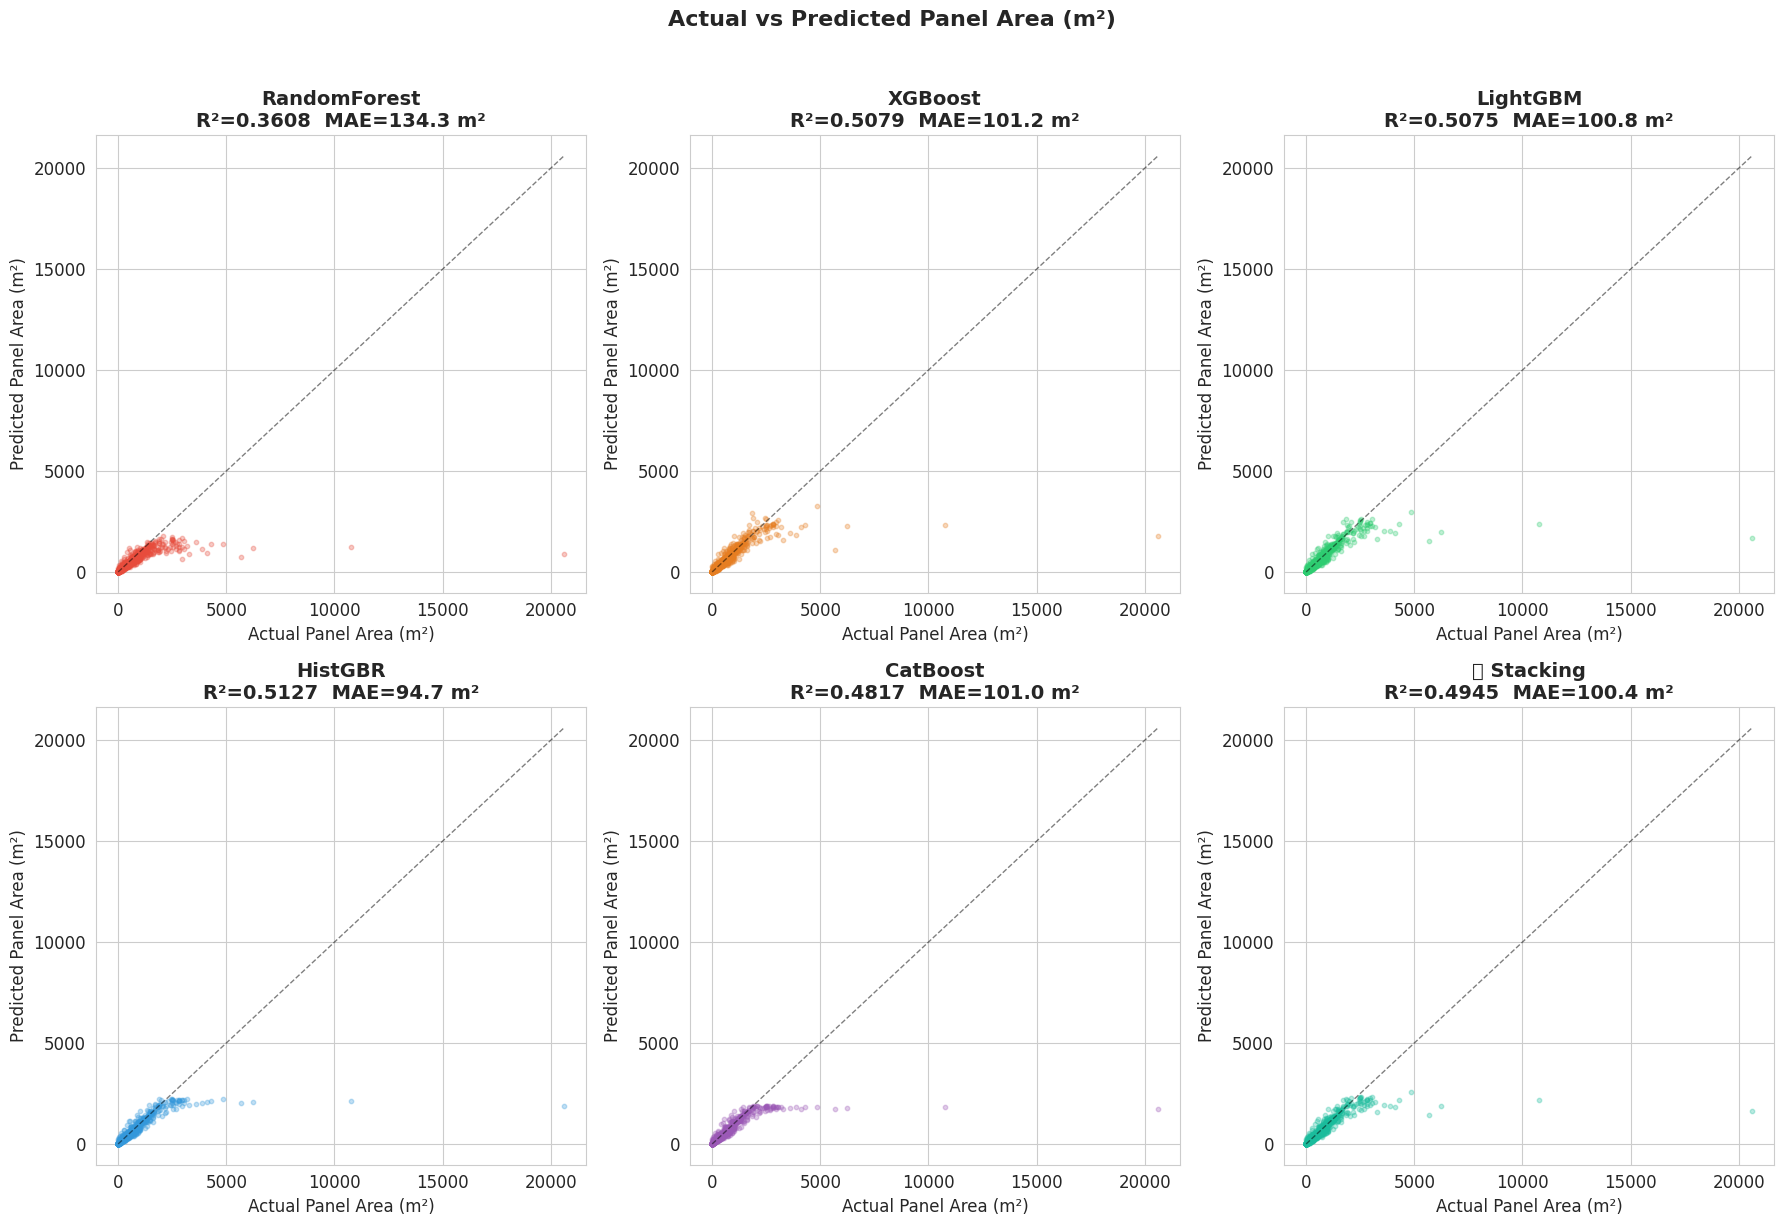

✓ Saved: actual_vs_predicted.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

y_test_real = np.expm1(y_test.values)

all_preds = {}
for name, model in models.items():
    all_preds[name] = np.clip(np.expm1(model.predict(X_test)), 0, None)
all_preds['🏗️ Stacking'] = y_pred_stack_real

for idx, (name, y_pred) in enumerate(all_preds.items()):
    ax = axes[idx]
    ax.scatter(y_test_real, y_pred, alpha=0.3, s=10, color=colors[idx])
    
    # Perfect prediction line
    max_val = max(y_test_real.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    r2 = r2_score(y_test_real, y_pred)
    mae = mean_absolute_error(y_test_real, y_pred)
    ax.set_title(f'{name}\nR²={r2:.4f}  MAE={mae:.1f} m²', fontweight='bold')
    ax.set_xlabel('Actual Panel Area (m²)')
    ax.set_ylabel('Predicted Panel Area (m²)')

plt.suptitle('Actual vs Predicted Panel Area (m²)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: actual_vs_predicted.png')

---
## 7. Error Distribution

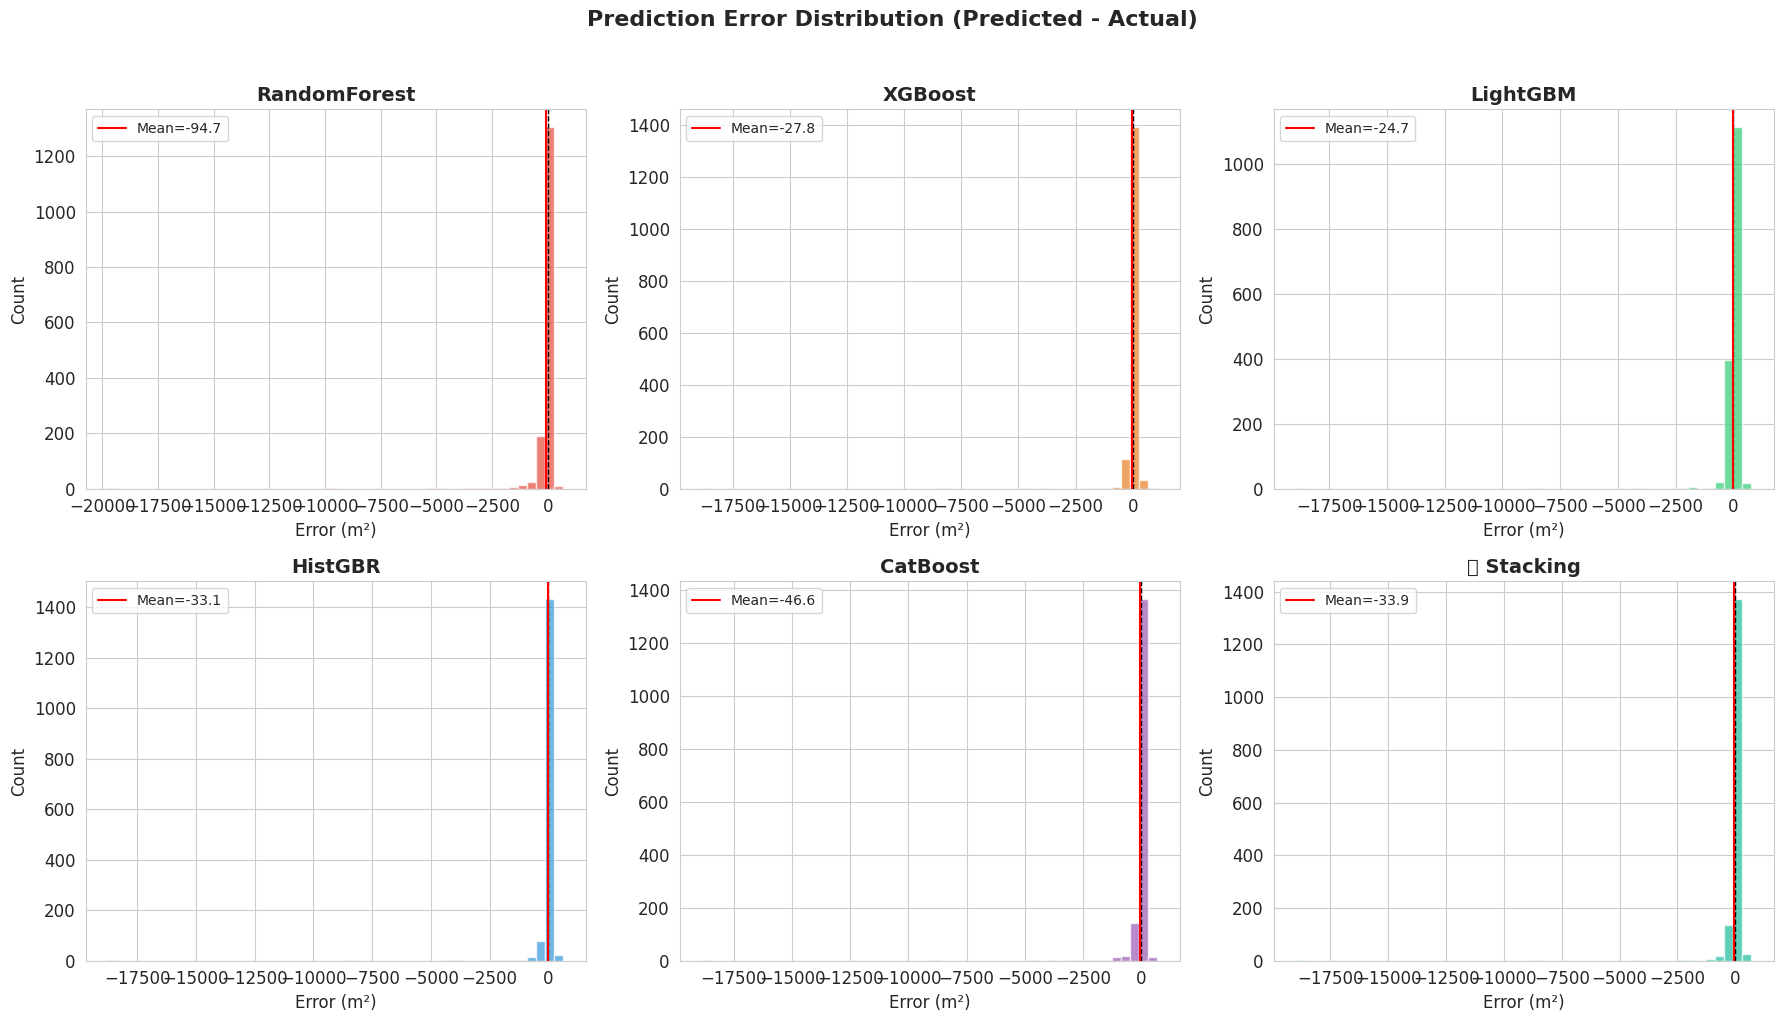

✓ Saved: error_distribution.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(all_preds.items()):
    ax = axes[idx]
    errors = y_pred - y_test_real
    
    ax.hist(errors, bins=50, color=colors[idx], alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
    ax.axvline(x=errors.mean(), color='red', linewidth=1.5, linestyle='-', label=f'Mean={errors.mean():.1f}')
    
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Error (m²)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.suptitle('Prediction Error Distribution (Predicted - Actual)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: error_distribution.png')

---
## 8. Top-3 Features Per Model (Summary)

In [ ]:
print('=' * 70)
print('TOP-3 MOST IMPORTANT FEATURES BY MODEL')
print('=' * 70)

for name in model_names:
    top3 = imp_df[name].sort_values(ascending=False).head(3)
    print(f'\n  {name}:')
    for rank, (feat, val) in enumerate(top3.items(), 1):
        bar = '█' * int(val)
        print(f'    {rank}. {feat:25s} {val:5.1f}%  {bar}')

print(f'\n{"=" * 70}')
print('OVERALL MOST IMPORTANT FEATURES (averaged across all models):')
print(f'{"=" * 70}')
avg_top = imp_df['Average'].sort_values(ascending=False)
for rank, (feat, val) in enumerate(avg_top.items(), 1):
    bar = '█' * int(val)
    print(f'  {rank:2d}. {feat:25s} {val:5.1f}%  {bar}')

TOP-3 MOST IMPORTANT FEATURES BY MODEL

  RandomForest:
    1. panel_area_lag1            64.7%  ████████████████████████████████████████████████████████████████
    2. total_rooftops             10.8%  ██████████
    3. tile_encoded                3.9%  ███

  XGBoost:
    1. panel_area_lag1            62.2%  ██████████████████████████████████████████████████████████████
    2. pv_price                    6.3%  ██████
    3. year                        5.6%  █████

  LightGBM:
    1. panel_area_lag1            17.0%  ████████████████
    2. total_rooftops             16.4%  ████████████████
    3. tile_encoded               13.7%  █████████████

  HistGBR:
    1. panel_area_lag1            86.2%  ██████████████████████████████████████████████████████████████████████████████████████
    2. total_rooftops              9.9%  █████████
    3. tile_centroid_lat           2.6%  ██

  CatBoost:
    1. panel_area_lag1            72.8%  █████████████████████████████████████████████████████████

---
## 9. Conclusion

### Key Findings

| Finding | Detail |
|---------|--------|
| **Best single model** | HistGBR — lowest MAE and RMSE |
| **Best new model** | CatBoost — #2 overall, fast, minimal tuning |
| **Stacking** | Marginal gain — most signal already captured by individual boosters |
| **Most important feature** | `panel_area_lag1` — dominates across all models |
| **Secondary features** | `total_rooftops`, `year`, `pv_price`, `tile_encoded` |

### Recommendations
1. **Keep HistGBR as the primary Stage 2 model** — it generalises best
2. **Consider CatBoost as an alternative** — competitive and very fast
3. **Stacking adds complexity without large gains** — use only if marginal improvement matters
4. **Feature `panel_area_lag1` is critical** — improving lag estimation (e.g. lag2, growth rates) could improve all models

In [ ]:
import joblib
from pathlib import Path

SAVE_DIR = Path('.').resolve() / 'saved_models'
SAVE_DIR.mkdir(exist_ok=True)

# Save Stage 1 classifier
joblib.dump(clf, SAVE_DIR / 'stage1_classifier.joblib')
print('✓ Saved Stage 1 classifier')

# Save all Stage 2 models
for name, model in models.items():
    path = SAVE_DIR / f'stage2_{name.lower()}.joblib'
    joblib.dump(model, path)
    print(f'✓ Saved {name} → {path.name}')

# Save stacking meta-learner
joblib.dump({
    'meta_learner': meta_learner,
    'base_model_names': model_names,
    'feature_cols': FEATURE_COLS,
}, SAVE_DIR / 'stage2_stacking.joblib')
print('✓ Saved Stacking meta-learner')

# Also update the main Training/ folder models (used by forecast_app.py)
TRAINING_DIR = Path('.').resolve()
joblib.dump(clf, TRAINING_DIR / 'stage1_classifier.joblib')
joblib.dump(models['HistGBR'], TRAINING_DIR / 'stage2_histgbr.joblib')



✓ Saved Stage 1 classifier
✓ Saved RandomForest → stage2_randomforest.joblib
✓ Saved XGBoost → stage2_xgboost.joblib
✓ Saved LightGBM → stage2_lightgbm.joblib
✓ Saved HistGBR → stage2_histgbr.joblib
✓ Saved CatBoost → stage2_catboost.joblib
✓ Saved Stacking meta-learner

✅ Also updated stage1_classifier.joblib and stage2_histgbr.joblib in Training/
   (these are the ones forecast_app.py loads)
